# 28 — Behavioral Cloning: Conditional Imitation Learning (CIL)

**Reference:** Codevilla et al. (2018) — *End-to-end Driving via Conditional Imitation Learning*

---

## Overview

This notebook trains a **CIL model** for intersection navigation in the Webots self-driving project.  
The model learns to steer the vehicle through intersections using **human demonstrations** recorded in V1.13.

### Key idea
Standard behavioral cloning (Notebook 27) learns a single steering policy.  
CIL extends it with a **navigation command input** that tells the model *which maneuver to execute*:

| Command | Value | When to press (PS4) | Expected behavior |
|---------|-------|---------------------|-------------------|
| LANE_FOLLOW | 0 | — (default) | Follow current lane, no CIL active |
| STRAIGHT | 1 | Circle (O) | Cross intersection straight ahead |
| LEFT | 2 | L1 | Turn left at intersection |
| RIGHT | 3 | R1 | Turn right at intersection |

---

## Architecture

Shared **DAVE-2 convolutional trunk** (input 320×160) extracts visual features,  
then routes them to one of **4 fully-connected branches** — one per command:

```
Image (3 × 160 × 320)
   │
   ▼  ── Shared DAVE-2 Conv Trunk ──────────────────────────────
   Conv(3→24, 5×5 s=2) → ELU
   Conv(24→36, 5×5 s=2) → ELU
   Conv(36→48, 5×5 s=2) → ELU
   Conv(48→64, 3×3) → ELU
   Conv(64→64, 3×3) → ELU
   Flatten → Dropout(0.5)
   FC(27456 → 1164) → ELU → Dropout(0.3)
   FC(1164 → 100) → ELU
   │
   ├── Branch 0  LANE_FOLLOW ──▶ FC(100→50)→ELU → FC(50→10)→ELU → FC(10→1)
   ├── Branch 1  STRAIGHT    ──▶ FC(100→50)→ELU → FC(50→10)→ELU → FC(10→1)
   ├── Branch 2  LEFT        ──▶ FC(100→50)→ELU → FC(50→10)→ELU → FC(10→1)
   └── Branch 3  RIGHT       ──▶ FC(100→50)→ELU → FC(50→10)→ELU → FC(10→1)
                                                                         │
                                                             steering_angle (rad)
```

During **training**, all 4 branches run a forward pass per batch; `torch.where` selects  
the correct branch output per sample using the command label. Gradients flow only to  
the selected branch for each sample.

During **inference**, `forward(image, command: int)` routes to a single branch.

---

## Dataset
- **Source:** `behavioral_dataset_CIL_06252026` — collected using V1.13 controller + `dataset_mode_v5.py`
- **Both lanes included:** LANE_LEFT (yellow line) and LANE_RIGHT (gravel edge)
- **`lane_side` is metadata only** — the model input is image + command, not lane side
- **4 Hz capture** when nav_command ≠ LANE_FOLLOW (intersection frames), 2 Hz otherwise

## Output
- **`models/cil_model.pt`** — TorchScript export, loaded by V1.14 controller at runtime
- Inference call: `angle = cil_model(image_tensor, nav_command)` → scalar steering angle (rad)

---
## 0. Setup & Imports

Standard scientific stack (NumPy, Pandas, OpenCV, Matplotlib) plus PyTorch and torchvision.

Run this cell first. It sets **random seeds** (SEED=42) for reproducibility across NumPy, Python random, and PyTorch (CPU + CUDA), and prints the active compute device.

> **Before running:** confirm `CUDA: True` and `Device: cuda` in the output.  
> Training on CPU is possible but roughly 10× slower per epoch.  
> If CUDA is not detected, check that the correct PyTorch+CUDA build is installed  
> (`pip show torch` → version should end in `+cu128` or similar).

In [39]:
import os
import random
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torchvision.transforms.functional as TF

print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device   : {DEVICE}")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

PyTorch  : 2.7.1+cu128
CUDA     : True
Device   : cuda


---
## 1. Configuration

All paths, hyperparameters, and preprocessing constants are defined here.  
**Edit this cell** when switching datasets, tuning training, or repointing the model output.

### Paths
| Variable | Purpose |
|----------|---------|
| `DATASET_DIR` | Root of the CIL dataset folder (contains `images/` and `measurements.csv`) |
| `MODEL_OUT` | Where `cil_model.pt` is saved after export (loaded by V1.14 controller) |

> **To use a different dataset session:** change `behavioral_dataset_CIL_06252026` to the new folder name. The rest of the path resolves automatically relative to the project root.

### Image preprocessing
The preprocessing here **must match `CILDataset._load_and_crop()` and the V1.14 controller exactly** — any mismatch will silently degrade inference quality:

| Constant | Value | Meaning |
|----------|-------|---------|
| `CROP_TOP` | 0.40 | Remove top 40% of frame (sky, irrelevant horizon) |
| `CROP_BOT` | 0.95 | Keep until 95% height (removes car hood) |
| `IMG_W × IMG_H` | 320 × 160 | Model input resolution |
| `NORM_MEAN/STD` | ImageNet | Standard normalization for DAVE-2 backbone |

### Training hyperparameters
| Constant | Value | Notes |
|----------|-------|-------|
| `BATCH_SIZE` | 32 | Increase to 64 if GPU memory allows |
| `EPOCHS` | 50 | Early stopping (patience=10) usually stops earlier |
| `LR` | 1e-4 | Adam optimizer; halved by scheduler on plateau |
| `WEIGHT_DECAY` | 1e-4 | L2 regularization |
| `VAL_SPLIT` | 0.20 | 80/20 stratified split by nav_command |

In [40]:
# ── Paths ──────────────────────────────────────────────────────────────
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
DATASET_DIR  = os.path.join(PROJECT_ROOT, 'data', 'behavioral_dataset_CIL_06252026')
IMAGES_DIR   = os.path.join(DATASET_DIR, 'images')
CSV_PATH     = os.path.join(DATASET_DIR, 'measurements.csv')
MODEL_DIR    = os.path.join(PROJECT_ROOT, 'models')
os.makedirs(MODEL_DIR, exist_ok=True)

MODEL_OUT    = os.path.join(MODEL_DIR, 'cil_model.pt')

print(f"Dataset  : {DATASET_DIR}")
print(f"CSV      : {CSV_PATH}")
print(f"Model out: {MODEL_OUT}")

# ── Nav command labels ─────────────────────────────────────────────────
CMD_LANE_FOLLOW = 0
CMD_STRAIGHT    = 1
CMD_LEFT        = 2
CMD_RIGHT       = 3
CMD_NAMES       = {0: 'LANE_FOLLOW', 1: 'STRAIGHT', 2: 'LEFT', 3: 'RIGHT'}
NUM_COMMANDS    = 4

# ── Image preprocessing ────────────────────────────────────────────────
# Original camera: W=620 × H=320
# Crop: remove top 40% (sky) and bottom 5% (hood)
CROP_TOP     = 0.40
CROP_BOT     = 0.95
IMG_W        = 320   # model input width
IMG_H        = 160   # model input height

# ImageNet normalization (standard for pretrain-compatible backbones)
NORM_MEAN = [0.485, 0.456, 0.406]
NORM_STD  = [0.229, 0.224, 0.225]

# ── Training hyperparameters ───────────────────────────────────────────
BATCH_SIZE   = 32
EPOCHS       = 50
LR           = 1e-4
WEIGHT_DECAY = 1e-4
PATIENCE     = 10    # early stopping patience
VAL_SPLIT    = 0.20

print(f"\nInput shape : (3, {IMG_H}, {IMG_W})")
print(f"Batch size  : {BATCH_SIZE}")
print(f"Epochs      : {EPOCHS}  (early stop patience={PATIENCE})")
print(f"LR          : {LR}")

Dataset  : d:\ML\Projects\Project_5_MR4010.10_Navegacion\MR4010.10_Navegacion\data\behavioral_dataset_CIL_06252026
CSV      : d:\ML\Projects\Project_5_MR4010.10_Navegacion\MR4010.10_Navegacion\data\behavioral_dataset_CIL_06252026\measurements.csv
Model out: d:\ML\Projects\Project_5_MR4010.10_Navegacion\MR4010.10_Navegacion\models\cil_model.pt

Input shape : (3, 160, 320)
Batch size  : 32
Epochs      : 50  (early stop patience=10)
LR          : 0.0001


---
## 2. Data Exploration

Load `measurements.csv` and inspect the raw dataset before any cleaning.

**What to look for:**
- **Nav command distribution** — LANE_FOLLOW will dominate (65-70% is normal). STRAIGHT/LEFT/RIGHT should each have at least 200 samples to train their branch meaningfully. If any intersection command has < 100 samples, collect more data before training.
- **Steering angle stats** — median near 0 (most frames are straight), std ~0.10–0.15 rad is typical. Large max values (> 0.65 rad) indicate sharp turns captured correctly.
- **Lane side split** — both LEFT and RIGHT should be present. The model sees `lane_side` only as metadata (not as an input), so imbalance is acceptable.

The three charts below show: command frequency, steering angle distribution per command, and lane side breakdown per command.

In [41]:
df = pd.read_csv(CSV_PATH)
print(f"Total rows    : {len(df):,}")
print(f"Columns       : {list(df.columns)}")
print(f"\nNav command distribution:")
for cmd, cnt in df['nav_command'].value_counts().sort_index().items():
    print(f"  {CMD_NAMES[cmd]:12s} ({cmd})  →  {cnt:5d}  ({cnt/len(df)*100:.1f}%)")
print(f"\nLane side distribution:")
for s, cnt in df['lane_side'].value_counts().sort_index().items():
    label = 'LEFT' if s == 0 else 'RIGHT'
    print(f"  {label:6s} ({s})  →  {cnt:5d}  ({cnt/len(df)*100:.1f}%)")
print(f"\nSteering angle stats:")
print(df['steering_angle'].describe())

Total rows    : 11,009
Columns       : ['contributor_id', 'session_id', 'timestamp', 'image_filename', 'steering_angle', 'speed_kmh', 'brake', 'autonomous_mode', 'lane_side', 'line_detected', 'edge_detected', 'gps_x', 'gps_y', 'lidar_obstacle_detected', 'lidar_obstacle_distance', 'behavior_class', 'nav_command', 'obstacle_type']

Nav command distribution:
  LANE_FOLLOW  (0)  →   6927  (62.9%)
  STRAIGHT     (1)  →    563  (5.1%)
  LEFT         (2)  →   2103  (19.1%)
  RIGHT        (3)  →   1416  (12.9%)

Lane side distribution:
  LEFT   (0)  →   1163  (10.6%)
  RIGHT  (1)  →   9846  (89.4%)

Steering angle stats:
count    11009.000000
mean        -0.001433
std          0.106803
min         -0.656100
25%          0.000000
50%          0.000000
75%          0.000000
max          0.639600
Name: steering_angle, dtype: float64


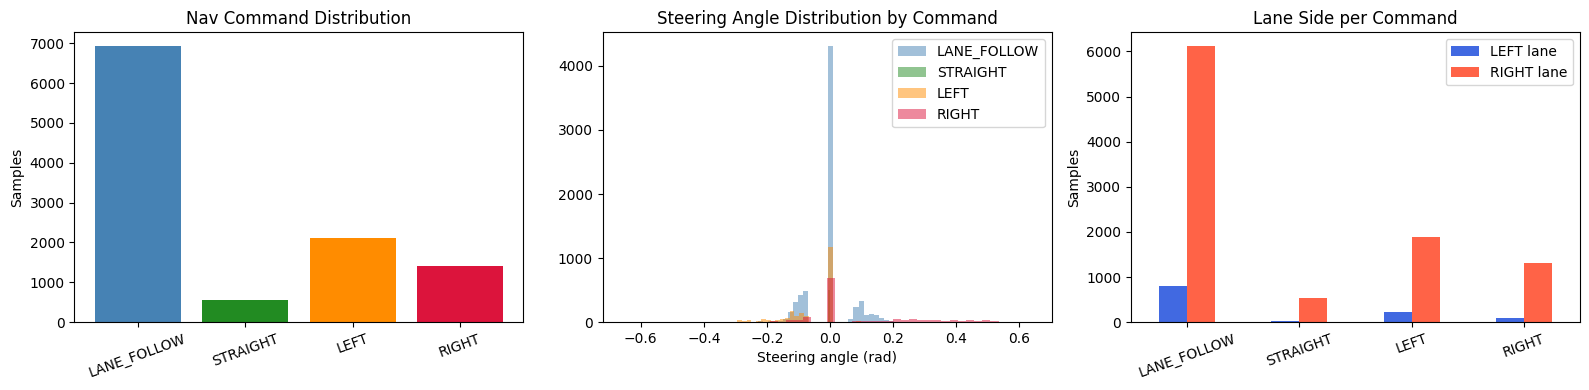

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Nav command bar chart
cmd_counts = df['nav_command'].value_counts().sort_index()
axes[0].bar([CMD_NAMES[i] for i in cmd_counts.index], cmd_counts.values,
            color=['steelblue', 'forestgreen', 'darkorange', 'crimson'])
axes[0].set_title('Nav Command Distribution')
axes[0].set_ylabel('Samples')
axes[0].tick_params(axis='x', rotation=20)

# Steering angle histogram per command
colors = ['steelblue', 'forestgreen', 'darkorange', 'crimson']
for cmd in range(NUM_COMMANDS):
    sub = df[df['nav_command'] == cmd]['steering_angle']
    axes[1].hist(sub, bins=50, alpha=0.5, label=CMD_NAMES[cmd], color=colors[cmd])
axes[1].set_title('Steering Angle Distribution by Command')
axes[1].set_xlabel('Steering angle (rad)')
axes[1].legend()

# Lane side breakdown per command
pivot = df.groupby(['nav_command', 'lane_side']).size().unstack(fill_value=0)
pivot.index = [CMD_NAMES[i] for i in pivot.index]
pivot.columns = ['LEFT lane', 'RIGHT lane']
pivot.plot(kind='bar', ax=axes[2], color=['royalblue', 'tomato'])
axes[2].set_title('Lane Side per Command')
axes[2].set_ylabel('Samples')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

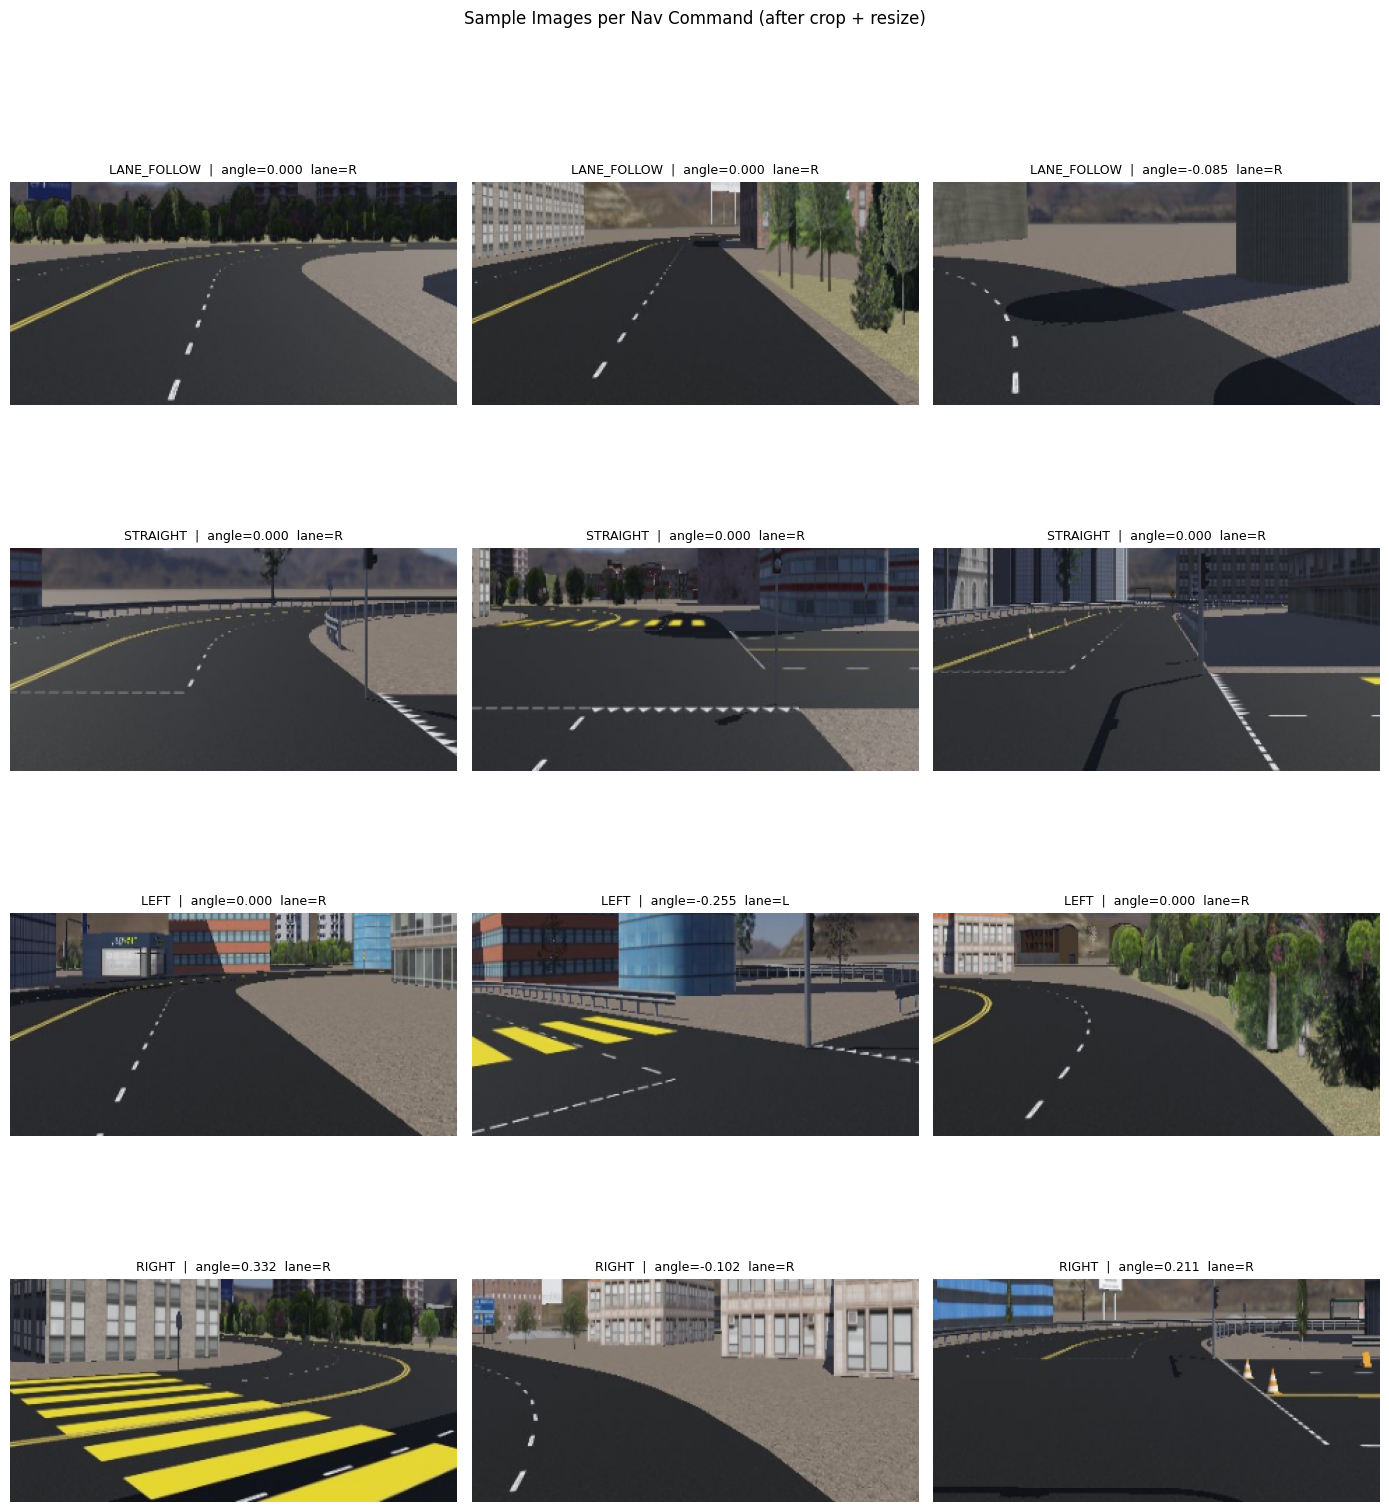

In [44]:
# Show sample images for each nav_command (3 per command)
fig, axes = plt.subplots(NUM_COMMANDS, 3, figsize=(14, 4 * NUM_COMMANDS))

for cmd in range(NUM_COMMANDS):
    samples = df[df['nav_command'] == cmd].sample(min(3, len(df[df['nav_command'] == cmd])),
                                                   random_state=SEED)
    for j, (_, row) in enumerate(samples.iterrows()):
        img_path = os.path.join(IMAGES_DIR, row['image_filename'])
        img = cv2.imread(img_path)
        if img is None:
            axes[cmd, j].set_visible(False)
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        # Apply crop for display
        h, w = img.shape[:2]
        y1, y2 = int(h * CROP_TOP), int(h * CROP_BOT)
        img_crop = cv2.resize(img[y1:y2, :], (IMG_W, IMG_H))
        axes[cmd, j].imshow(img_crop)
        axes[cmd, j].set_title(
            f"{CMD_NAMES[cmd]}  |  angle={row['steering_angle']:.3f}  "
            f"lane={'L' if row['lane_side']==0 else 'R'}",
            fontsize=9)
        axes[cmd, j].axis('off')

plt.suptitle('Sample Images per Nav Command (after crop + resize)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

---
## 2b. Data Cleaning

Mirrors the cleaning logic from Notebook 27, adapted for CIL-specific columns.

### Steps applied
1. **Manual-only filter** — keep `autonomous_mode == 0` (human driving demonstrations only). Autonomous frames from BC/PID would teach the model to imitate the old controller, not the human.
2. **Image existence check** — drop any row whose image file is missing from disk. Avoids `FileNotFoundError` crashing the DataLoader mid-training.
3. **NaN drop + type cast** — `nav_command`, `lane_side`, `edge_detected`, `line_detected` must be clean integers for the Dataset class.
4. **False-intersection inspection** — rows labeled STRAIGHT/LEFT/RIGHT where the lane reference (gravel edge or yellow line) is **fully visible** likely mean the PS4 button was pressed too early — the car was still on the straight approaching the intersection. These frames teach the branch the wrong association (intersection command + straight road view). The table shows counts for review.

### `CLEAN_FALSE_INTERSECTION` flag
Set to `True` after reviewing the table if you want to remove those early-press frames.  
Start with `False` (default) to keep all data on the first training run.  
Re-run from this cell and retrain if you enable it.

In [45]:
# 1. Expert demos only (autonomous_mode == 0 → human demonstrations)
df = df[df['autonomous_mode'] == 0].copy()
print(f"After manual-only filter : {len(df):,} rows")

# 2. Image existence check
df['_img_path'] = df['image_filename'].apply(lambda f: os.path.join(IMAGES_DIR, f))
missing = ~df['_img_path'].apply(os.path.exists)
if missing.sum() > 0:
    print(f"WARNING: {missing.sum()} missing images — dropped")
df = df[~missing].drop(columns=['_img_path']).copy()
print(f"After image check        : {len(df):,} rows")

# 3. Drop NaN and cast types
df = df.dropna(subset=['steering_angle', 'speed_kmh', 'brake', 'nav_command']).copy()
df['nav_command']   = df['nav_command'].astype(int)
df['lane_side']     = df['lane_side'].astype(int)
df['edge_detected'] = df['edge_detected'].fillna(0).astype(int)
df['line_detected'] = df['line_detected'].fillna(0).astype(int)
df = df.reset_index(drop=True)
print(f"After NaN drop           : {len(df):,} rows")

# 4. Inspect intersection command rows for suspicious frames
# Analogous to N27's EVADING/no-VEHICLE filter:
# nav_command ∈ {1,2,3} rows where lane reference is fully visible may be
# early presses before the intersection was actually reached.
intersection_cmds = df['nav_command'].isin([CMD_STRAIGHT, CMD_LEFT, CMD_RIGHT])
print(f"\nIntersection command rows: {intersection_cmds.sum()}")
print(f"\n  {'Command':10s}  {'Total':>6s}  {'Lane ref visible':>16s}  {'In intersection':>15s}")
print("  " + "-" * 55)
for cmd in [CMD_STRAIGHT, CMD_LEFT, CMD_RIGHT]:
    sub     = df[df['nav_command'] == cmd]
    has_ref = (sub['edge_detected'] == 1) | (sub['line_detected'] == 1)
    print(f"  {CMD_NAMES[cmd]:10s}  {len(sub):6d}  {has_ref.sum():16d}  {(~has_ref).sum():15d}")

# Remove intersection-labeled rows where lane reference is fully visible
# (likely false early presses — car still on straight, not at intersection yet).
# Set True after reviewing the table above.
CLEAN_FALSE_INTERSECTION = False
if CLEAN_FALSE_INTERSECTION:
    has_ref   = (df['edge_detected'] == 1) | (df['line_detected'] == 1)
    false_int = intersection_cmds & has_ref
    removed   = false_int.sum()
    df        = df[~false_int].copy().reset_index(drop=True)
    print(f"\nRemoved {removed} suspected false-intersection rows")

print(f"\nFinal cleaned dataset    : {len(df):,} rows")
print("\nNav command distribution after cleaning:")
for cmd, cnt in df['nav_command'].value_counts().sort_index().items():
    print(f"  {CMD_NAMES[cmd]:12s} ({cmd})  →  {cnt:5d}  ({cnt/len(df)*100:.1f}%)")

After manual-only filter : 10,983 rows
After image check        : 10,983 rows
After NaN drop           : 10,983 rows

Intersection command rows: 4057

  Command      Total  Lane ref visible  In intersection
  -------------------------------------------------------
  STRAIGHT       544               261              283
  LEFT          2097               370             1727
  RIGHT         1416               524              892

Final cleaned dataset    : 10,983 rows

Nav command distribution after cleaning:
  LANE_FOLLOW  (0)  →   6926  (63.1%)
  STRAIGHT     (1)  →    544  (5.0%)
  LEFT         (2)  →   2097  (19.1%)
  RIGHT        (3)  →   1416  (12.9%)


---
## 3. Dataset Class — `CILDataset`

Custom PyTorch `Dataset` that returns `(image_tensor, nav_command, steering_angle)` for each sample.

### Preprocessing pipeline (must match V1.14 controller exactly)
```
BGR image (620×320, raw from camera)
  → RGB conversion
  → Crop: rows [40%h : 95%h]   ← removes sky and car hood
  → Resize to 320×160  (W×H)
  → float32 / 255
  → ImageNet normalization: mean=[0.485,0.456,0.406]  std=[0.229,0.224,0.225]
```

### Augmentation (training split only, disabled for validation)
| Augmentation | Probability | Notes |
|-------------|-------------|-------|
| Horizontal flip | 50% | Mirrors steering angle; swaps LEFT↔RIGHT command labels |
| Brightness jitter | 100% | Random factor ∈ [0.70, 1.30] simulates lighting variation |

The flip command swap is critical: a LEFT-turn scene flipped horizontally is visually identical to a RIGHT-turn scene, so the command label must swap too or the model learns contradictory examples.

### Output per sample
| Return value | Type | Shape/value |
|---|---|---|
| `image_tensor` | float32 tensor | `(3, 160, 320)` normalized |
| `nav_command` | Python int | ∈ {0, 1, 2, 3} |
| `steering_angle` | float32 tensor | scalar (radians) |

In [46]:
class CILDataset(Dataset):
    """
    Returns (image_tensor, nav_command, steering_angle) for each sample.
    Augmentation (flip + brightness) is applied only when augment=True (training set).
    """

    def __init__(self, df, images_dir, augment=False):
        self.df         = df.reset_index(drop=True)
        self.images_dir = images_dir
        self.augment    = augment
        self.mean       = torch.tensor(NORM_MEAN).view(3, 1, 1)
        self.std        = torch.tensor(NORM_STD).view(3, 1, 1)

    def __len__(self):
        return len(self.df)

    def _load_and_crop(self, filename):
        path = os.path.join(self.images_dir, filename)
        img  = cv2.imread(path)
        if img is None:
            raise FileNotFoundError(f"Image not found: {path}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        y1, y2 = int(h * CROP_TOP), int(h * CROP_BOT)
        img = img[y1:y2, :]
        img = cv2.resize(img, (IMG_W, IMG_H))
        return img

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = self._load_and_crop(row['image_filename'])
        angle = float(row['steering_angle'])
        cmd   = int(row['nav_command'])

        # ── Augmentation (training only) ───────────────────────────
        if self.augment:
            # Horizontal flip — mirrors angle
            if random.random() > 0.5:
                img   = np.fliplr(img).copy()
                angle = -angle
                # LEFT/RIGHT commands flip too
                if cmd == CMD_LEFT:
                    cmd = CMD_RIGHT
                elif cmd == CMD_RIGHT:
                    cmd = CMD_LEFT

            # Brightness jitter
            factor = random.uniform(0.70, 1.30)
            img    = np.clip(img.astype(np.float32) * factor, 0, 255).astype(np.uint8)

        # ── To tensor + normalize ──────────────────────────────────
        tensor = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
        tensor = (tensor - self.mean) / self.std

        return tensor, cmd, torch.tensor(angle, dtype=torch.float32)

---
## 4. Train / Val Split & DataLoaders

### Stratified 80/20 split
The dataset is split by `nav_command` (stratified) so every command class appears in both train and val at the same proportions. This prevents any branch from being evaluated only on training data.

### Balancing with `WeightedRandomSampler`
LANE_FOLLOW accounts for ~65% of raw samples. Without rebalancing, the model would optimize mostly for LANE_FOLLOW and underfit the intersection branches.

**Inverse-frequency weighting** assigns `weight_i = total / n_i` per sample, so each batch sees ~25% of every command regardless of raw frequency. The `compute_class_weights` function prints the effective balance so you can verify it.

> **Note:** The sampler is only applied to the **training** DataLoader. The validation DataLoader uses raw class frequencies (no rebalancing) so the per-branch MAE in the training log reflects real-world distribution.

### Sanity check cell
The cell below the DataLoader setup draws 8 training samples to verify images look correctly cropped, normalized colors, and command labels match the image content.

In [47]:
from sklearn.model_selection import train_test_split

# Stratified split by nav_command so all commands appear in both sets
df_train, df_val = train_test_split(
    df,
    test_size=VAL_SPLIT,
    stratify=df['nav_command'],
    random_state=SEED
)

print(f"Train samples: {len(df_train):,}")
print(f"Val   samples: {len(df_val):,}")


def compute_class_weights(df_split, cmd_names):
    """
    Inverse-frequency weights so that every nav_command gets equal batch representation.

    Formula: weight_i = total / n_i
    Effect:  n_i * weight_i = total  for every command i
             → each command contributes ~(100 / N_commands)% of each batch.

    Advantage over manual weights: recalculates automatically when dataset grows
    or new sessions are added — no hand-tuning needed.
    """
    total = len(df_split)
    weights = {
        c: total / max((df_split['nav_command'] == c).sum(), 1)
        for c in range(NUM_COMMANDS)
    }

    # Compute effective representation to verify balance
    total_eff = sum((df_split['nav_command'] == c).sum() * weights[c]
                    for c in range(NUM_COMMANDS))

    print(f"\n  {'Cmd':<3} {'Name':12} {'n':>6}  {'weight':>8}  {'n × weight':>10}  {'% batch':>8}")
    print("  " + "-" * 55)
    for c, name in cmd_names.items():
        n   = (df_split['nav_command'] == c).sum()
        w   = weights[c]
        eff = n * w
        pct = 100 * eff / total_eff
        print(f"  {c:<3} {name:12} {n:>6}  {w:>8.2f}  {eff:>10.1f}  {pct:>7.1f}%")

    return weights


print("Train command distribution + automatic class weights:")
CMD_WEIGHTS = compute_class_weights(df_train, CMD_NAMES)

# ── WeightedRandomSampler — one weight per training row ───────────────
sample_weights = df_train['nav_command'].map(CMD_WEIGHTS).values
sampler = WeightedRandomSampler(
    weights=torch.tensor(sample_weights, dtype=torch.float32),
    num_samples=len(sample_weights),
    replacement=True
)

ds_train = CILDataset(df_train, IMAGES_DIR, augment=True)
ds_val   = CILDataset(df_val,   IMAGES_DIR, augment=False)

dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, sampler=sampler,
                      num_workers=0, pin_memory=True)
dl_val   = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=0, pin_memory=True)

print(f"\nTrain batches: {len(dl_train)}")
print(f"Val   batches: {len(dl_val)}")

Train samples: 8,786
Val   samples: 2,197
Train command distribution + automatic class weights:

  Cmd Name              n    weight  n × weight   % batch
  -------------------------------------------------------
  0   LANE_FOLLOW    5541      1.59      8786.0     25.0%
  1   STRAIGHT        435     20.20      8786.0     25.0%
  2   LEFT           1677      5.24      8786.0     25.0%
  3   RIGHT          1133      7.75      8786.0     25.0%

Train batches: 275
Val   batches: 69


Batch shape  : torch.Size([32, 3, 160, 320])
Commands     : [3, 0, 2, 1, 1, 0, 0, 1]
Angles (rad) : ['-0.000', '0.000', '0.074', '-0.000', '0.000', '0.102', '0.000', '-0.000']


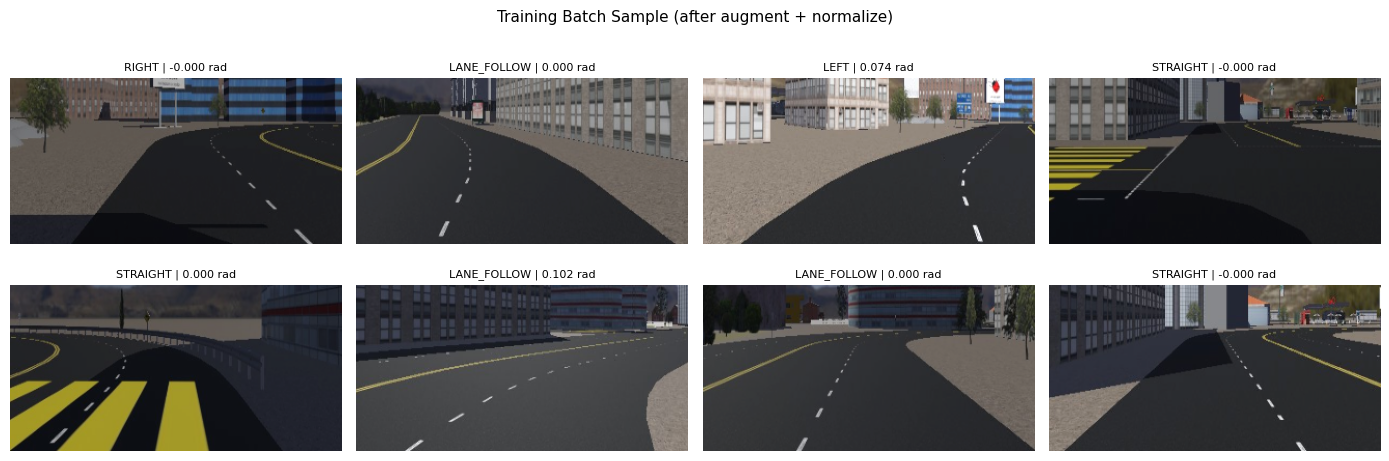

In [48]:
# Quick sanity check — visualise one batch
imgs, cmds, angles = next(iter(dl_train))
print(f"Batch shape  : {imgs.shape}")
print(f"Commands     : {cmds[:8].tolist()}")
print(f"Angles (rad) : {[f'{a:.3f}' for a in angles[:8].tolist()]}")

mean_t = torch.tensor(NORM_MEAN).view(3,1,1)
std_t  = torch.tensor(NORM_STD).view(3,1,1)

fig, axes = plt.subplots(2, 4, figsize=(14, 5))
for i, ax in enumerate(axes.flat):
    if i >= imgs.size(0): break
    img_display = (imgs[i] * std_t + mean_t).permute(1,2,0).clamp(0,1).numpy()
    ax.imshow(img_display)
    ax.set_title(f"{CMD_NAMES[cmds[i].item()]} | {angles[i]:.3f} rad", fontsize=8)
    ax.axis('off')
plt.suptitle('Training Batch Sample (after augment + normalize)', fontsize=11)
plt.tight_layout()
plt.show()

---
## 5. CIL Model Architecture — `CILModel`

The model follows the Codevilla 2018 design: a shared perception backbone feeds into four independent steering branches, one per navigation command.

### Shared trunk (DAVE-2 conv + FC)
```
Input: (batch, 3, 160, 320)

Conv(3→24,  5×5 s=2) → ELU   # 160×320 → 78×158
Conv(24→36, 5×5 s=2) → ELU   # 78×158  → 37×77
Conv(36→48, 5×5 s=2) → ELU   # 37×77   → 17×37
Conv(48→64, 3×3)     → ELU   # 17×37   → 15×35
Conv(64→64, 3×3)     → ELU   # 15×35   → 13×33

Flatten → 27,456 features
Dropout(0.5)
FC(27456 → 1164) → ELU
Dropout(0.3)
FC(1164  → 100)  → ELU
```

### Four branch heads (one per command)
```
FC(100 → 50) → ELU
FC(50  → 10) → ELU
FC(10  →  1)            ← steering angle (rad)
```

### Training vs inference
- **Training** (`forward_train`): all 4 branches run; `torch.where` selects the correct output per sample using the command tensor. Avoids boolean-mask device issues on PyTorch 2.7+CUDA.
- **Inference** (`forward`): routes to a single branch via Python `if/elif` on the scalar `command: int`. TorchScript-compatible.

### Smoke test
Two cells follow the model definition: one verifies `forward_train` output shape `[batch]`, one verifies `forward(cmd=2)` output shape. Both must print `expected [4]` before training.

---
## 6. Training Loop

### Loss and optimizer
- **MSE loss** on steering angle (radians). Squared penalty pushes the model to eliminate large errors first.
- **Adam** with `lr=1e-4`, `weight_decay=1e-4`.
- **ReduceLROnPlateau**: halves LR after 5 epochs without val improvement; floor at 1e-6.
- **Gradient clipping**: `max_norm=1.0` prevents exploding gradients from rare large-angle samples.

### Early stopping
Training halts after `PATIENCE=10` consecutive epochs with no val improvement. Best weights are restored at the end.

### Per-branch MAE in the log
Each epoch prints the validation MAE for all 4 branches (e.g., `LANE=0.042  STRA=0.022  LEFT=0.074  RIGH=0.077`). This lets you spot if a specific branch is underperforming without running the full evaluation cell.

> **Device note:** `cmds` is intentionally **not** moved to DEVICE before `forward_train`. The method casts `commands` internally via `.to(device=f.device, dtype=torch.long)`. Moving `cmds` to DEVICE in the training loop and then using it as a boolean mask on CPU `angles` would cause a device mismatch on PyTorch 2.7+CUDA.

### Reading the output
- `✓` = new best val loss saved
- `(no improve N/PATIENCE)` = countdown to early stop
- `lr→X.Xe-0Y` = learning rate was just reduced by the scheduler

In [49]:
def _make_branch():
    return nn.Sequential(
        nn.Linear(100, 50), nn.ELU(),
        nn.Linear(50, 10),  nn.ELU(),
        nn.Linear(10, 1),
    )


class CILModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.trunk_conv = nn.Sequential(
            nn.Conv2d(3,  24, kernel_size=5, stride=2), nn.ELU(),
            nn.Conv2d(24, 36, kernel_size=5, stride=2), nn.ELU(),
            nn.Conv2d(36, 48, kernel_size=5, stride=2), nn.ELU(),
            nn.Conv2d(48, 64, kernel_size=3),           nn.ELU(),
            nn.Conv2d(64, 64, kernel_size=3),           nn.ELU(),
        )

        flat = self._flat_size()
        print(f"[CILModel] Conv output flat size: {flat:,}")

        self.trunk_fc = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(flat, 1164), nn.ELU(),
            nn.Dropout(0.3),
            nn.Linear(1164, 100), nn.ELU(),
        )

        self.branch_0 = _make_branch()  # LANE_FOLLOW
        self.branch_1 = _make_branch()  # STRAIGHT
        self.branch_2 = _make_branch()  # LEFT
        self.branch_3 = _make_branch()  # RIGHT

    def _flat_size(self):
        with torch.no_grad():
            x = self.trunk_conv(torch.zeros(1, 3, IMG_H, IMG_W))
            return int(x.numel())

    def _trunk(self, x: torch.Tensor) -> torch.Tensor:
        return self.trunk_fc(self.trunk_conv(x))

    def forward(self, x: torch.Tensor, command: int) -> torch.Tensor:
        """Inference — single scalar command for the whole batch."""
        f = self._trunk(x)
        if command == 0:
            return self.branch_0(f).squeeze(-1)
        elif command == 1:
            return self.branch_1(f).squeeze(-1)
        elif command == 2:
            return self.branch_2(f).squeeze(-1)
        else:
            return self.branch_3(f).squeeze(-1)

    def forward_train(self, x: torch.Tensor, commands: torch.Tensor) -> torch.Tensor:
        """Training — per-sample branch selection via torch.where (no index ops).

        All 4 branches run forward; torch.where picks the right output per sample.
        commands is explicitly cast to the feature device to avoid CPU/CUDA mismatch.
        Gradients flow only to the selected branch per sample (where is differentiable).
        """
        f  = self._trunk(x)
        b0 = self.branch_0(f).squeeze(-1)
        b1 = self.branch_1(f).squeeze(-1)
        b2 = self.branch_2(f).squeeze(-1)
        b3 = self.branch_3(f).squeeze(-1)
        # Force commands onto the same device+dtype as f — avoids any DataLoader
        # device-mismatch between the collated CPU LongTensor and CUDA features.
        c = commands.to(device=f.device, dtype=torch.long)
        return torch.where(c == 0, b0,
               torch.where(c == 1, b1,
               torch.where(c == 2, b2, b3)))


model = CILModel().to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params    : {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

[CILModel] Conv output flat size: 27,456
Total params    : 32,230,080
Trainable params: 32,230,080


In [50]:
# Forward pass smoke test
with torch.no_grad():
    dummy_img = torch.zeros(4, 3, IMG_H, IMG_W).to(DEVICE)
    dummy_cmd = torch.tensor([0, 1, 2, 3]).to(DEVICE)
    out = model.forward_train(dummy_img, dummy_cmd)
    print(f"forward_train output shape : {out.shape}  (expected [4])")
    out2 = model.forward(dummy_img, 2)
    print(f"forward (cmd=2) output shape: {out2.shape}  (expected [4])")

forward_train output shape : torch.Size([4])  (expected [4])
forward (cmd=2) output shape: torch.Size([4])  (expected [4])


In [51]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6)

history = {
    'train_loss': [], 'val_loss': [],
    'branch_val_mae': {CMD_NAMES[c]: [] for c in range(NUM_COMMANDS)},
}

best_val_loss  = float('inf')
best_weights   = None
no_improve     = 0

for epoch in range(1, EPOCHS + 1):

    # ── Train ──────────────────────────────────────────────────────
    model.train()
    train_loss_sum = 0.0
    for imgs, cmds, angles in dl_train:
        imgs   = imgs.to(DEVICE)
        angles = angles.to(DEVICE)

        optimizer.zero_grad()
        preds = model.forward_train(imgs, cmds)   # cmds cast inside forward_train
        loss  = criterion(preds, angles)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss_sum += loss.item()

    train_loss = train_loss_sum / len(dl_train)

    # ── Validate ───────────────────────────────────────────────────
    model.eval()
    val_loss_sum  = 0.0
    branch_errors = {c: [] for c in range(NUM_COMMANDS)}

    with torch.no_grad():
        for imgs, cmds, angles in dl_val:
            imgs   = imgs.to(DEVICE)
            angles = angles.to(DEVICE)

            preds        = model.forward_train(imgs, cmds)
            val_loss_sum += criterion(preds, angles).item()

            errors   = (preds - angles).abs()
            cmds_cpu = cmds.cpu()
            for c in range(NUM_COMMANDS):
                mask = (cmds_cpu == c)
                if mask.any():
                    branch_errors[c].extend(errors[mask.to(DEVICE)].cpu().tolist())

    val_loss = val_loss_sum / len(dl_val)
    prev_lr  = optimizer.param_groups[0]['lr']
    scheduler.step(val_loss)
    cur_lr   = optimizer.param_groups[0]['lr']

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    for c in range(NUM_COMMANDS):
        mae = float(np.mean(branch_errors[c])) if branch_errors[c] else 0.0
        history['branch_val_mae'][CMD_NAMES[c]].append(mae)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights  = {k: v.clone() for k, v in model.state_dict().items()}
        no_improve    = 0
        flag = ' ✓'
    else:
        no_improve += 1
        flag = f'  (no improve {no_improve}/{PATIENCE})'

    lr_tag     = f'  lr→{cur_lr:.1e}' if cur_lr != prev_lr else ''
    branch_str = '  '.join(
        f"{CMD_NAMES[c][:4]}={history['branch_val_mae'][CMD_NAMES[c]][-1]:.4f}"
        for c in range(NUM_COMMANDS)
    )
    print(f"Ep {epoch:3d}/{EPOCHS}  train={train_loss:.5f}  val={val_loss:.5f}  "
          f"[{branch_str}]{flag}{lr_tag}")

    if no_improve >= PATIENCE:
        print(f"Early stopping at epoch {epoch}")
        break

model.load_state_dict(best_weights)
print(f"\nBest val loss: {best_val_loss:.5f}")

Ep   1/50  train=0.00780  val=0.00623  [LANE=0.0443  STRA=0.0196  LEFT=0.0712  RIGH=0.0906] ✓
Ep   2/50  train=0.00600  val=0.00617  [LANE=0.0423  STRA=0.0154  LEFT=0.0602  RIGH=0.1030] ✓
Ep   3/50  train=0.00552  val=0.00598  [LANE=0.0444  STRA=0.0145  LEFT=0.0516  RIGH=0.0914] ✓
Ep   4/50  train=0.00501  val=0.00603  [LANE=0.0440  STRA=0.0159  LEFT=0.0639  RIGH=0.0837]  (no improve 1/10)
Ep   5/50  train=0.00468  val=0.00615  [LANE=0.0434  STRA=0.0146  LEFT=0.0540  RIGH=0.0980]  (no improve 2/10)
Ep   6/50  train=0.00476  val=0.00536  [LANE=0.0451  STRA=0.0175  LEFT=0.0522  RIGH=0.0770] ✓
Ep   7/50  train=0.00436  val=0.00555  [LANE=0.0437  STRA=0.0135  LEFT=0.0569  RIGH=0.0815]  (no improve 1/10)
Ep   8/50  train=0.00432  val=0.00555  [LANE=0.0412  STRA=0.0156  LEFT=0.0521  RIGH=0.0918]  (no improve 2/10)
Ep   9/50  train=0.00406  val=0.00537  [LANE=0.0411  STRA=0.0135  LEFT=0.0603  RIGH=0.0673]  (no improve 3/10)
Ep  10/50  train=0.00384  val=0.00507  [LANE=0.0397  STRA=0.0149  LEF

---
## 7. Evaluation

Three evaluation cells run after training:

### Cell 1 — Per-branch metrics table
Collects predictions for the entire validation set, split by nav_command. Reports per-branch **MAE**, **RMSE**, and **max error** (all in radians).

Typical acceptable ranges for this dataset:
| Command | MAE target |
|---------|-----------|
| LANE_FOLLOW | < 0.05 rad (~3°) |
| STRAIGHT | < 0.04 rad (~2°) |
| LEFT | < 0.10 rad (~6°) |
| RIGHT | < 0.10 rad (~6°) |

LEFT and RIGHT have inherently higher variance because intersection geometry varies, so slightly higher MAE is expected.

> **Device pattern used here:** `cmds` is moved to DEVICE for `forward_train`, but the boolean mask is moved back to CPU (`.cpu()`) before indexing `angles` (which is on CPU). The CUDA mask is used only when indexing `preds` (also on CUDA). This two-tensor pattern avoids the PyTorch 2.7 device mismatch error.

### Cell 2 — Predicted vs ground truth scatter (one plot per branch)
Points on the diagonal = perfect prediction. Horizontal scatter = the model is stuck at a fixed angle. Useful for diagnosing systematic bias in a branch.

### Cell 3 — Visual inspection
Shows 4 random val images per branch with `pred / gt / Δ` overlay. Green title = error < 0.05 rad; red = larger. Quick sanity check that the model is steering in the right direction for each maneuver type.

In [52]:
# Per-branch evaluation table
model.eval()
all_preds  = {c: [] for c in range(NUM_COMMANDS)}
all_labels = {c: [] for c in range(NUM_COMMANDS)}

with torch.no_grad():
    for imgs, cmds, angles in dl_val:
        imgs  = imgs.to(DEVICE)
        cmds  = cmds.to(DEVICE)
        preds = model.forward_train(imgs, cmds)
        for c in range(NUM_COMMANDS):
            mask     = (cmds == c).cpu()   # move mask to CPU so both tensors match
            if mask.any():
                all_preds[c].extend(preds[mask.to(DEVICE)].cpu().tolist())
                all_labels[c].extend(angles[mask].tolist())

print(f"{'Command':14s}  {'Samples':>7s}  {'MAE (rad)':>9s}  {'RMSE (rad)':>10s}  {'Max err':>8s}")
print('-' * 58)
for c in range(NUM_COMMANDS):
    if not all_labels[c]:
        print(f"{CMD_NAMES[c]:14s}  {'N/A':>7s}")
        continue
    p  = np.array(all_preds[c])
    gt = np.array(all_labels[c])
    mae  = np.mean(np.abs(p - gt))
    rmse = np.sqrt(np.mean((p - gt)**2))
    maxe = np.max(np.abs(p - gt))
    print(f"{CMD_NAMES[c]:14s}  {len(p):7d}  {mae:9.4f}  {rmse:10.4f}  {maxe:8.4f}")

Command         Samples  MAE (rad)  RMSE (rad)   Max err
----------------------------------------------------------
LANE_FOLLOW        1385     0.0345      0.0522    0.4318
STRAIGHT            109     0.0150      0.0284    0.1546
LEFT                420     0.0433      0.0664    0.3151
RIGHT               283     0.0544      0.0824    0.4842


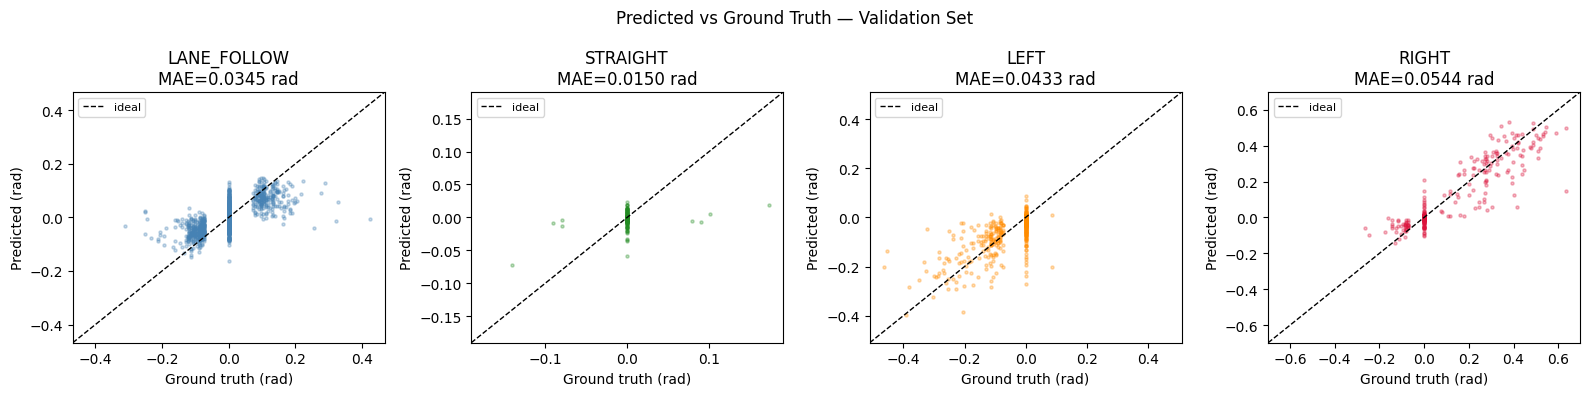

In [53]:
# Scatter: predicted vs ground truth per branch
# (uses all_preds / all_labels collected in the cell above)
fig, axes = plt.subplots(1, NUM_COMMANDS, figsize=(16, 4))
colors = ['steelblue', 'forestgreen', 'darkorange', 'crimson']

for c, (ax, col) in enumerate(zip(axes, colors)):
    if not all_labels[c]:
        ax.set_visible(False)
        continue
    p  = np.array(all_preds[c])
    gt = np.array(all_labels[c])
    ax.scatter(gt, p, alpha=0.3, s=5, color=col)
    lim = max(abs(gt).max(), abs(p).max()) * 1.1
    ax.plot([-lim, lim], [-lim, lim], 'k--', lw=1, label='ideal')
    ax.set_xlabel('Ground truth (rad)')
    ax.set_ylabel('Predicted (rad)')
    ax.set_title(f"{CMD_NAMES[c]}\nMAE={np.mean(np.abs(p-gt)):.4f} rad")
    ax.legend(fontsize=8)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)

plt.suptitle('Predicted vs Ground Truth — Validation Set', fontsize=12)
plt.tight_layout()
plt.show()

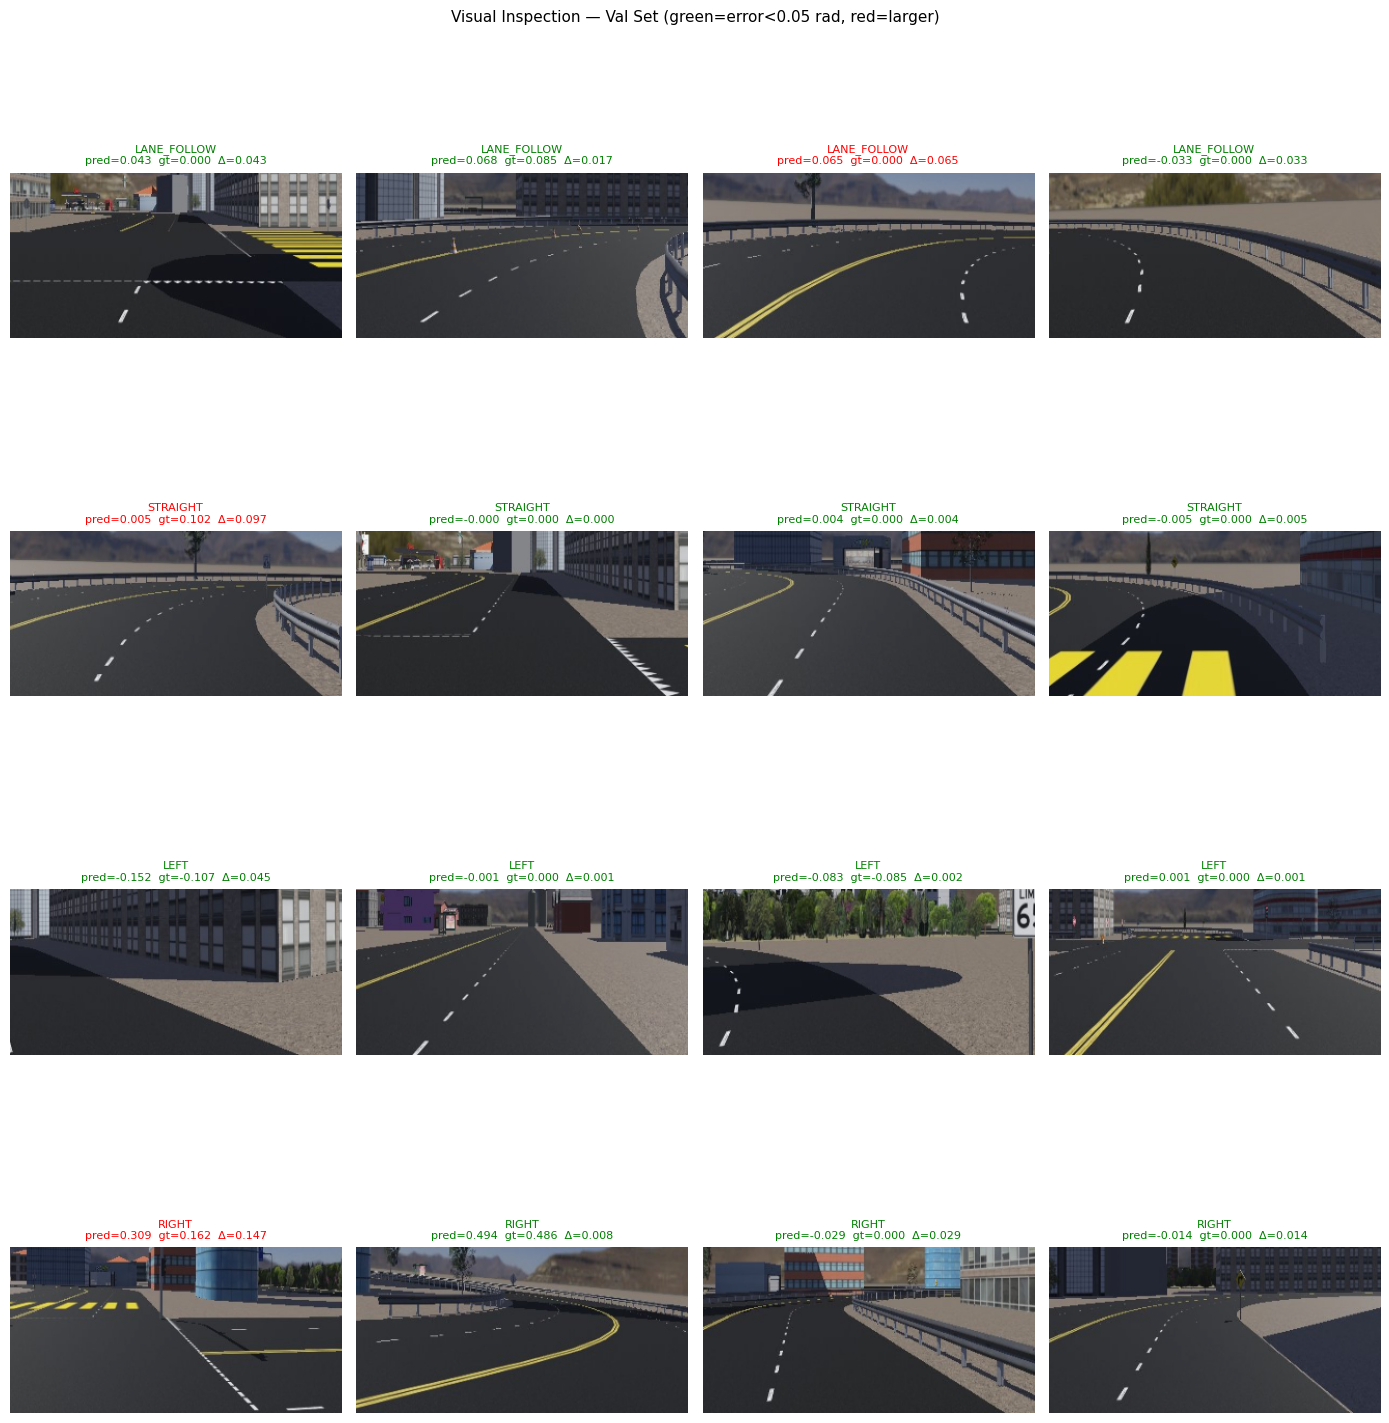

In [54]:
# Visual inspection — 4 random val images per branch with predicted overlay
model.eval()
mean_t = torch.tensor(NORM_MEAN).view(3,1,1)
std_t  = torch.tensor(NORM_STD).view(3,1,1)

fig, axes = plt.subplots(NUM_COMMANDS, 4, figsize=(14, 4 * NUM_COMMANDS))

for c in range(NUM_COMMANDS):
    sub = df_val[df_val['nav_command'] == c].sample(
        min(4, len(df_val[df_val['nav_command'] == c])), random_state=SEED)
    ds_single = CILDataset(sub, IMAGES_DIR, augment=False)

    for j in range(len(ds_single)):
        img_t, cmd, gt = ds_single[j]
        with torch.no_grad():
            pred = model.forward(img_t.unsqueeze(0).to(DEVICE), int(cmd))
            pred = pred.item()

        img_display = (img_t * std_t + mean_t).permute(1,2,0).clamp(0,1).numpy()
        axes[c, j].imshow(img_display)
        color = 'green' if abs(pred - gt.item()) < 0.05 else 'red'
        axes[c, j].set_title(
            f"{CMD_NAMES[c]}\npred={pred:.3f}  gt={gt.item():.3f}  Δ={abs(pred-gt.item()):.3f}",
            fontsize=8, color=color)
        axes[c, j].axis('off')

plt.suptitle('Visual Inspection — Val Set (green=error<0.05 rad, red=larger)', fontsize=11)
plt.tight_layout()
plt.show()

---
## 8. TorchScript Export

Exports the trained model to `models/cil_model.pt` using `torch.jit.script`.

### Why TorchScript?
The V1.14 Webots controller is a plain Python script — it cannot import the `CILModel` class defined in this notebook. TorchScript serializes the model graph + weights into a self-contained `.pt` file that any Python process can load with `torch.jit.load`, no class definition required.

### Export requirements
- `forward(x: Tensor, command: int) → Tensor` must use only TorchScript-compatible ops (no Python dicts, no dynamic shapes). The current implementation is fully compatible.
- The model must be in `.eval()` mode before scripting to disable dropout.

### Verification
After saving, the cell immediately reloads the `.pt` file and runs one inference per branch with a zero-input dummy tensor. Expected output: 4 non-zero angles (the model biases from training), one per command. All 4 must complete without error to confirm the export is valid.

### File location
```
<project_root>/models/cil_model.pt
```
This path is hardcoded in V1.14 via `_CIL_MODEL_PATH`. If you retrain with a new dataset, just re-run this cell — the controller picks up the updated file on next launch.

In [55]:
model.eval()
scripted = torch.jit.script(model)
scripted.save(MODEL_OUT)
print(f"Saved TorchScript model → {MODEL_OUT}")

# Verify round-trip: load and run one inference per branch
loaded = torch.jit.load(MODEL_OUT, map_location=DEVICE)
loaded.eval()

dummy = torch.zeros(1, 3, IMG_H, IMG_W, device=DEVICE)
print("\nInference smoke test (loaded .pt):")
with torch.no_grad():
    for c in range(NUM_COMMANDS):
        out = loaded(dummy, c)
        print(f"  command={c} ({CMD_NAMES[c]:12s}) → angle={out.item():.4f} rad")

Saved TorchScript model → d:\ML\Projects\Project_5_MR4010.10_Navegacion\MR4010.10_Navegacion\models\cil_model.pt

Inference smoke test (loaded .pt):
  command=0 (LANE_FOLLOW ) → angle=-0.0074 rad
  command=1 (STRAIGHT    ) → angle=-0.0007 rad
  command=2 (LEFT        ) → angle=-0.0475 rad
  command=3 (RIGHT       ) → angle=0.0432 rad


---
## 9. V1.14 Controller Integration

This section is a reference for how `cil_model.pt` is used inside `simple_controller_act_2_1_V1.14.py`. No code needs to be run here — the controller handles everything at runtime.

### Model loading (controller startup)
```python
cil_model = torch.jit.load(_CIL_MODEL_PATH, map_location='cpu')
cil_model.eval()
```
Loads on CPU at startup. On GPU-less machines it still works; inference is fast enough at 10 Hz for a single 320×160 image.

### Preprocessing (must match `CILDataset._load_and_crop` exactly)
```python
h, w  = frame_bgr.shape[:2]
y1    = int(h * 0.40);  y2 = int(h * 0.95)
crop  = frame_bgr[y1:y2, :]
rgb   = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
img   = cv2.resize(rgb, (320, 160))
t     = torch.from_numpy(img).permute(2,0,1).float() / 255.0
mean  = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std   = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
tensor = ((t - mean) / std).unsqueeze(0)   # → (1, 3, 160, 320)
```

### Inference in the main loop
```python
nav_cmd = dataset_mode.get_nav_command()   # int ∈ {0,1,2,3}
with torch.no_grad():
    raw_angle = cil_model(tensor, nav_cmd).item()
# EMA smoothing (α=0.40)
smoothed = 0.40 * raw_angle + 0.60 * prev_smoothed
angle    = float(np.clip(smoothed, -0.70, 0.70))
```

### Arbitration priority in V1.14
```
[1] Evasion phase 1  (obstacle ahead, turn away)
[2] Evasion phase 2  (turn, then straighten)
[3] LiDAR emergency stop
[4] LiDAR slow zone
[5] CIL active  ← nav_cmd ∈ {LEFT, RIGHT, STRAIGHT}
[6] BC Mode A   (BC model + PID + line detected + normal behavior)
[7] BC Mode B   (BC model only)
[8] PID Mode C  (PID only)
[9] Safe hold Mode D
```
CIL is bypassed if any of the safety layers above it are active.  
BC/PID is bypassed while CIL is active (`cil_active = True`).

### Nav command lifecycle
1. Press PS4 **L1** (LEFT), **R1** (RIGHT), or **Circle** (STRAIGHT) before the intersection
2. Controller latches the command → `dataset_mode.set_nav_command(cmd)`
3. CIL activates, overrides steering at fixed speed 15 km/h
4. After **3 seconds** (NAV_CMD_RESET_DELAY) the command auto-resets to LANE_FOLLOW
5. BC/PID resumes normal lane following

### ADAS monitor CIL row
The monitor panel (W=400, H=971) shows a **CIL model** row:
- `ACTIVE  (LEFT/RIGHT/STRAIGHT)` in gold — CIL is currently steering
- `LOADED  (standby)` in green — model loaded, waiting for nav command
- `NOT FOUND  (fallback→BC/PID)` in red — `.pt` file missing, CIL disabled